## 5.3 전이 학습
일반적으로 합성곱 신경망 기반의 딥러닝 모델을 제대로 훈련시키려면 많은 양의 데이터가 필요하다. 그런데 불행히도 충분히 큰 데이터셋을 얻는 것은 쉽지 않다. 큰 데이터셋을 확보하려면 돈과 시간이 필요하기 때문이다. 이러한 현실적인 어려움을 해결한 것이 전이 학습이다. 전이 학습이란 이미지넷처럼 아주 큰 데이터셋을 써서 훈련된 모델의 가중치를 가져와 우리가 해결하려는 과제에 맞게 보정해서 사용하는 것을 의미한다. 이때 아주 큰 데이터셋을 사용하여 훈련된 모델을 사전 훈련된 모델(네트워크)이라고 한다. 결과적으로 비교적 적은 수의 데이터를 가지고도 우리가 원하는 과제를 해결할 수 있다.

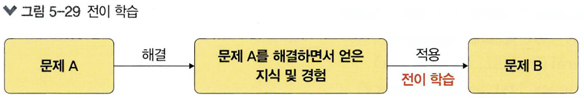

전이 학습을 위한 방법으로는 특성 추출과 미세 조정 기법이 있다. 특성 추출 기법부터 하나씩 살펴보겠다.


### 5.3.1 특성 추출 기법
특성 추출은 ImageNet 데이터셋으로 사전 훈련된 모델을 가져온 후 마지막에 완전연결층 부분만 새로 만든다. 즉, 학습할 때는 마지막 완전연결층(이미지의 카테고리를 결정하는 부분)만 학습하고 나머지 계층들은 학습되지 않도록 한다. 특성 추출은 이미지 분류를 위해 두 부분으로 구성된다.
- 합성곱층: 합성곱층과 풀링층으로 구성
- 데이터 분류기(완전연결층): 추출된 특성을 입력받아 최종적으로 이미지에 대한 클래스를 분류하는 부분

사전 훈련된 네트워크의 합성곱층(가중치 고정)에 새로운 데이터를 통과시키고, 그 출력을 데이터 분류기에서 훈련시킨다. 여기에서 사용 가능한 이미지 분류 모델은 다음과 같다. Xception, Inception V3, ResNet50, VGG16. VGG19, MobileNet

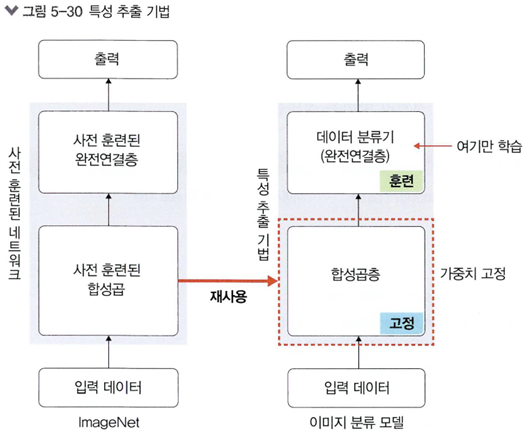

특성 추출에 대해 예시를 진행하기에 앞서 필요한 라이브러리를 설치한다.

In [1]:
pip install opencv-python

OpenCV는 Open Source Computer Vision Library의 약어로 오픈 소스 컴퓨터 비전 라이브러리이다. 특히 OpenCV-Python 라이브러리를 설치하면 파이썬에서도 사용 가능하다. 먼저 필요한 모든 라이브러리를 호출한다.

In [2]:
import os
import time
import copy
import glob
import cv2  #앞에서 설치한 OpenCV 라이브러리
import shutil

import torch
import torchvision  #컴퓨터 비전(computer vision) 용도의 패키지
import torchvision.transforms as transforms  #데이터 전처리를 위해 사용되는 패키지
import torchvision. models as models  #다양한 파이토치 네트워크를 사용할 수 있도록 도와주는 패키지
import torch.nn as nn
import torch.optim as optim
from torch .utils.data import DataLoader
import matplotlib.pyplot as plt

예제에서 사용할 이미지 데이터에 대한 전처리 방법을 정의한다.

In [3]:
from google.colab import drive
drive.mount('/content/drive')
data_path = '/content/drive/MyDrive/catanddog/train'
#이미지 데이터가 위치한 경로 지정
transform = transforms.Compose(
    [transforms.Resize([256, 256]) ,
     transforms.RandomResizedCrop(224) ,
     transforms.RandomHorizontalFlip() ,
     transforms.ToTensor()])
train_dataset = torchvision.datasets.ImageFolder(data_path,transform=transform)
train_loader = torch.utils.data.DataLoader( train_dataset, batch_size=32, num_workers=8, shuffle=True)
print(len(train_dataset))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
385


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


- 1 torchvision.transform은 이미지 데이터를 변환하여 모델(네트워크)의 입력으로 사용할 수 있게 변환해줍니다. 이때 사용되는 파라미터는 다음과 같습니다.

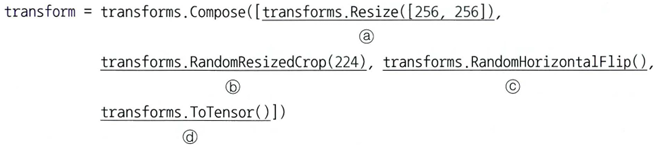

 + Resize: 이미지의 크기를 조정. 즉, 256 x 256 크기로 이미지 데이터를 조정한다.
 + RandomResizedCrop: 이미지를 랜덤한 크기 및 비율로 자른다. Resize와 RandomResizedCrop 모두 이미지를 자르는 데 사용하지만 그 용도는 다르다. Resize가 합성곱층을 통과하기 위해 이미지 크기를 조정하는 전처리 과정이라면, RandomResizedCrop은 데이터 확장 용도로 사용된다. RandomResizedCrop은 이미지를 랜덤한 비율로 자른 후 데이터 크기를 조정한다.
 + c RandomHorizontalFlip: 이미지를 랜덤하게 수평으로 뒤집는다.
 + d ToTensor: 이미지 데이터를 텐서로 변환한다.

 - 2 datasets.ImageFolder는 데이터로더가 데이터를 불러올 대상(혹은 경로)과 방법(혹은 전처리)을 정의하며, 사용하는 파라미터는 다음과 같다.

  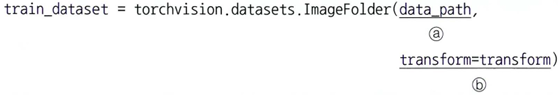

   + 첫 번째 파라미터: 불러올 데이터가 위치한 경로
   + transform: 이미지 데이터에 대한 전처리

  - 3 데이터로더는 데이터를 불러오는 부분으로 앞에서 정의한 ImageFolder(train_dataset)을 데이터로더에 할당하는데, 이때 한 번에 불러올 데이터양을 결정하는 batch_size를 지정한다. 또한, 추가적으로 데이터를 무작위로 섞을 것인지도 설정한다. 데이터로더에서 사용하는 파라미터는 다음과 같다.

  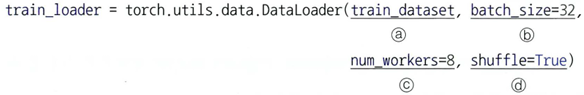

   + a 첫 번째 파라미터: 데이터셋을 지정한다.
   + b batch_size: 한 번에 불러올 때 데이터양을 결정하는 배치 크기를 설정한다.
   + c num_workers: 데이터를 불러올 때 하위 프로세스를 몇 개 사용할지 설정하는데, 이때 너무 많은 하위 프로세스를 설정하게 되면 오류가 발생하거나 메모리 부족 현상이 발생할 수 있다.
   + d shuffle: 데이터를 무작위로 섞을지를 지정한다. shuffle=True로 설정하면 데이터를 무작위로 섞어서 랜덤으로 불러온다.
  
  다음은 train_dataset에 포함된 데이터의 개수를 출력한 결과이다.

  385

개와 고양이 이미지 데이터는 전체 이미지를 사용할 경우 CPU에서 과부화가 발생하여 일부 이미지만 사용했다.


- RandomResizedCrop 자세히 알아보기
RandomResizedCrop으로 데이터가 확장하는 방법에 대해 코드로 살펴볼 텐데, 먼저 다음 명령을 실행하여 mxnet을 설치한다. mxnet 설치가 완료된 후에는 커널을 재시작해야 한다.

In [4]:
#pip install --user mxnet

In [5]:
#import matplotlib.pyplot as plt
#import mxnet as mx
#from mxnet.gluon.data.vision import transforms
#example_image = mx.image.imread ("../chap05/data/cat.jpg")  #예제를 진행할 이미지 불러오기
#plt.imshow(example_image . asnumpy())

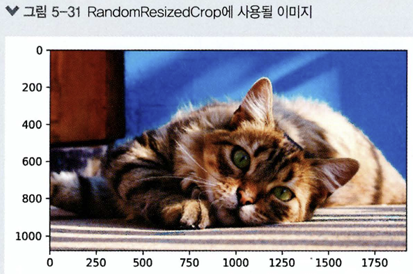

불러온 이미지에 RandomResizedCrop을 적용하기 위한 함수를 생성한다.

In [6]:
#def show_images(imgs , num_rows , num_cols, scale=2):
#  aspect_ratio = imgs[0].shape[0]/imgs[0].shape[1] # 확장할 이미지의 크기 조정
#  figsize = (num_cols * scale, num_rows * scale * aspect_ratio)
#  _, axes = plt.subplots(num_rows , num_cols, figsize=figsize)
#  for i in range(num_rows) :
#    for j in range(num_cols):
#      axes[i][j].imshow(imgs[i * num_cols + j].asnumpy())
#      axes [i] [j].axes.get_xaxis().set_visible(False)  # x축 전체를 숨김
#      axes [i] [j].axes.get_yaxis().set_visible(False)  # y축 전체를 숨김
#  plt.subplots_adjust(hspace=0.1 , wspace=0)
#  return axes

#def apply(img , aug, num_rows=2, num_cols=4, scale=3):
#  Y = [aug(img) for _ in range(num_rows * num_cols )]  # 다양한 샘플을 얻기 위해 여러 번 데이터 확장
#  show_images (Y, num_rows , num_cols, scale)

# RandomResizedCrop이 적용된 이미지를 출력합니다.
#shape_aug = transforms.RandomResizedCrop( size=(200, 200), scale=( 0.1 , 1), ratio=(0.5, 2))
#apply(example_image, shape_aug )

# 이때 RandomResizedCrop에 적용된 파라미터는 다음과 같습니다.
#shape_aug = transforms.RandomResizedCrop(size=( 200, 200 ), scale=(0.1, 1) , ratio=(0.5, 2) )

- a size: 출력할 크기를 200 x 200으로 조정한다.
- b scale: 면적 비율을 0.1~1(10~100%) 범위 내에서 무작위로 자른다.
- c ration: 면적의 너비와 높이 비율을 0.5~2 범위 내에서 무작위로 조절한다.

즉, ratio를 통해 너비와 비율을 조절한 후 scale을 통해 자르고, 최종적으로 출력할 size로 조정된다.

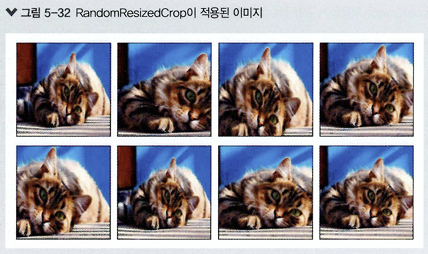

이미지 데이터를 불러왔으니 24개의 이미지에 대해 레이블 정보와 함께 출력해본다.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


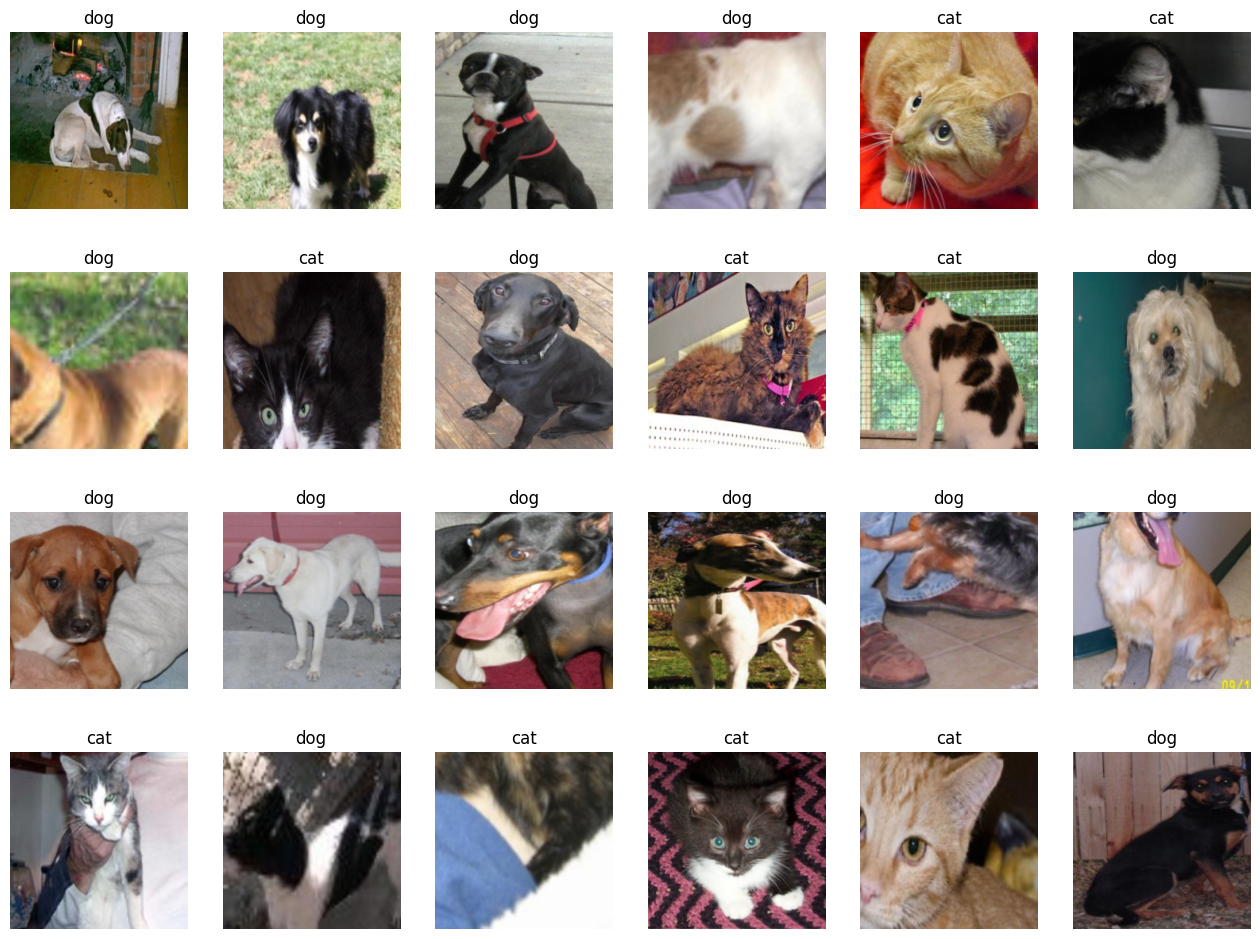

In [7]:
import numpy as np
import matplotlib.pyplot as plt

samples, labels = next(iter(train_loader))

classes = {0: 'cat', 1: 'dog'}

fig = plt.figure(figsize=(16, 24))

for i in range(24):
    a = fig.add_subplot(4, 6, i + 1)
    a.set_title(classes[labels[i].item()])
    a.axis('off')
    a.imshow(np.transpose(samples[i].numpy(), (1, 2, 0)))

plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)
plt.show()

- 1 반복자(iterator, for 구문과 같은 효과)를 사용하려면 iter()와 next()가 필요하다. iter()는 전달된 데이터의 반복자를 꺼내 반환하며, next()는 그 반복자가 다음에 출력해야 할 요소를 반환한다. 즉, iter()로 반복자를 구하고 그 반복자를 next()에 전달하여 차례대로 꺼낼 수 있다. 앞의 코드에서 반복자는 train_loader가 되기 때문에 train_loader에서 samples와 labels의 값을 순차적으로 꺼내서 저장한다. 간단히 정리하면 train_loader에서 데이터를 하나씩 꺼내 오겠다는 의미이다.
- 2 np.transpose는 다음 그림과 같이 행과 열을 바꿈으로써 행렬의 차원을 바꾸어 준다.

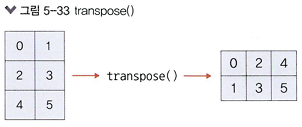

일반적으로 행렬의 차원을 변경하는 이유는 행렬의 내적 연산 때문이다. 다음 그림과 같이 A라는 행렬과 B라는 행렬의 내적 결과는 C가 된다. 이때 A 행렬의 행과 B 행렬의 열의 수가 같아야 내적이 가능하다. A와 B의 행과 열의 수가 달라 내적이 불가능할 때는 np.transpose()나 np.reshape() 등으로 차원을 조정해야 한다.

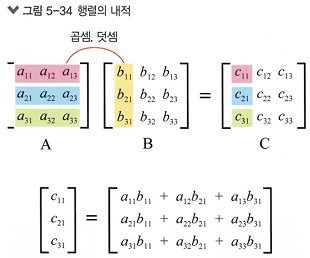

print(samples.shape)을 통해 데이터의 형태를 확인해보면 torch.Size([32,3,224,224])가 출력된다. 이 상태 그대로(np.transpose를 적용하지 않으면) 'Invalid shape (3,224,224) for image data'와 같은 오류가 발생한다. 따라서 np.traspose(samples[i].numpy(), (1,2,0))을 사용해서 (224,224,3)과 같은 형태로 변환한 후 사용해야 한다. 예를 들어 다음과 같은 변환이 가능하다.



In [8]:
exam = np.arange(24).reshape(2,3,4)
exam

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [9]:
np.transpose(exam,(2,1,0))

array([[[ 0, 12],
        [ 4, 16],
        [ 8, 20]],

       [[ 1, 13],
        [ 5, 17],
        [ 9, 21]],

       [[ 2, 14],
        [ 6, 18],
        [10, 22]],

       [[ 3, 15],
        [ 7, 19],
        [11, 23]]])

데이터가 준비됐으므로 사전 훈련된 ResNet18 모델을 내려받습니다.

In [10]:
resnet18 = models.resnet18(pretrained=True) # pretrained=True는 사전 학습된 가중치를 사용하겠다는 의미

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


- ResNet18
ResNet18은 50개의 계층으로 구성된 합성곱 신경망이다. ImageNet 데이터 베이스의 100만 개가 넘는 영상을 이용하여 훈련된 신경망으로 전이 학습에 사용되도록 사전 훈련된 모델을 제공하고 있다. 하지만 ResNet18은 입력 제약이 매우 므고, 충분한 메모리(RAM)가 없으면 학습 속도가 느릴 수 있다는 단점이 있다.

- 사전 훈련된 모델
파이토치는 다음과 같은 방법으로 무작위의 가중치로 모델을 구성할 수 있다.

In [11]:
import torchvision.models as models
resnet18 = models .resnet18()
alexnet = models .alexnet()
vgg16 = models .vgg16()
squeezenet = models .squeezenet1_0()
densenet = models .densenet161()
inception = models .inception_v3()
googlenet = models .googlenet()
shufflenet = models .shufflenet_v2_x1_0()
mobilenet_v2 = models .mobilenet_v2()
mobilenet_v3_large = models .mobilenet_v3_large()
mobilenet_v3_small = models .mobilenet_v3_small()
resnext50_32x4d = models .resnext50_32x4d()
wide_resnet50_2 = models .wide_resnet50_2()
mnasnet = models .mnasnet1_0()

/usr/local/lib/python3.12/dist-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


또한, 다음과 같은 방법을 이용하여 사전 학습된 모델(사전 학습된 모델의 가중치 값)을 사용할 수 있습니다. 다음의 모델들이 사용하는 것과 같이 pretrained=True로 설정하여 사용하면 됩니다.

In [12]:
import torchvision.models as models
resnet18 = models .resnet18(pretrained=True)
alexnet = models .alexnet(pretrained=True )
squeezenet = models .squeezenet1_0 (pretrained=True )
vgg16 = models .vgg16(pretrained=True )
densenet = models .densenet161(pretrained=True )
inception = models .inception_v3(pretrained=True )
googlenet = models .googlenet(pretrained=True )
shufflenet = models .shufflenet_v2_x1_0( pretrained=True)
mobilenet_v2 = models .mobilenet_v2( pretrained=True )
mobilenet_v3_large = models .mobilenet_v3_large(pretrained=True )
mobilenet_v3_small = models .mobilenet_v3_small(pretrained=True )
resnext50_32x4d = models .resnext50_32x4d( pretrained=True )
wide_resnet50_2 = models .wide_resnet50_2(pretrained=True )
mnasnet = models .mnasnet1_0( pretrained=True )

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_0_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be rem

다음은 내려받은 ResNet18의 합성곱층을 사용하되 파라미터에 대해서는 학습을 하지 않도록 고정시킵니다.

In [13]:
def set_parameter_requires_grad(model , feature_extracting=True ):
  if feature_extracting:
    for param in model .parameters():
      param.requires_grad = False  #1

set_parameter_requires_grad(resnet18)

- 1 역전파 중 파라미터들에 대한 변화를 계산할 필요가 없음을 나타낸다. 즉, 모델의 일부를 고정하고 나머지를 학습하고자 할 때 requires_grad=False로 설정한다. 이때 모델의 일부는 합성곱층과 풀링층을 의미한다. 내려받은 ResNet18의 마지막 부분에 완전연결층을 추가한다. 추가된 완전연결층은 개와 고양이 클래스를 분류하는 용도로 사용된다.

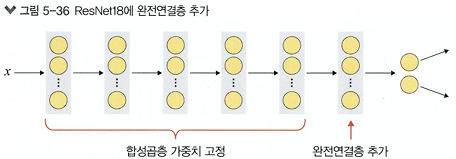

In [14]:
resnet18.fc = nn.Linear(512 , 2)  # 2는 클래스가 두 개라는 의미

참고용으로 모델의 파라미터 값들을 확인해보겠습니다.

In [15]:
for name, param in resnet18.named_parameters( ): # model.named_parameters()는 모델에 접근하여 파라미터 값들을 가져올 때 사용
  if param.requires_grad:
    print(name, param.data)

fc.weight tensor([[-0.0247, -0.0143, -0.0108,  ...,  0.0344,  0.0018, -0.0089],
        [ 0.0289,  0.0355,  0.0051,  ..., -0.0212,  0.0332,  0.0293]])
fc.bias tensor([0.0331, 0.0181])


다음은 파라미터 값들을 가져온 결과이다. 다음 결과와 같이 파라미터는 weight와 bias가 사용되고 있다. 이제 모델 학습 준비를 위해 모델의 객체를 생성하고 손실 함수를 정의한다.

In [16]:
model = models.resnet18( pretrained=True ) #모델의 객체 생성

for param in model. parameters (): #모델의 합성곱층 가중치 고정
  param. requires_grad = False

model.fc = torch.nn.Linear(512, 2)
for param in model. fc. parameters (): #완전연결층은 학습
  param .requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss ()  #손실 함수 정의
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

다음은 내려받은 ResNet18 모델의 마지막에 완전연결층을 추가한 모델을 보여준다. 데이터 준비 및 네트워크 생성이 완료되었으므로 이제 모델을 학습시켜야 한다. 모델 학습을 위한 함수를 생성한다.

In [27]:
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=13, is_train=True):
    since = time.time()
    acc_history = []
    loss_history = []
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders:
            inputs = inputs.to(device)
            labels = labels.to(device)

            model.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(dataloaders.dataset)
        epoch_acc = running_corrects.double() / len(dataloaders.dataset)

        print('Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))

        if epoch_acc > best_acc:
            best_acc = epoch_acc

        acc_history.append(epoch_acc.item())
        loss_history.append(epoch_loss)

        # 여기! 매 epoch 끝날 때 모델 저장
        torch.save(
            model.state_dict(),
            os.path.join('/content/drive/MyDrive/catanddog', '{:0=2d}.pth'.format(epoch))
        )

    time_elapsed = time.time() - since

    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60,
        time_elapsed % 60
    ))

    print('Best Acc: {:.4f}'.format(best_acc))

    return acc_history, loss_history

그리고 마지막으로 ResNet18에 추가된 완전연결층은 학습을 하도록 설정합니다. 학습을 통해 얻어지는 파라미터를 옵티마이저에 전달해서 최종적으로 모델 학습에 사용합니다.

In [28]:
params_to_update = []
for name , param in resnet18.named_parameters():
  if param .requires_grad == True:
    params_to_update.append(param) # 파라미터 학습 결과를 저장
    print('\t', name)

optimizer = optim.Adam(params_to_update) # 학습 결과를 옵티마이저에 전달

	 fc.weight
	 fc.bias


다음은 완전연결층의 어떤 파라미터들이 옵티마이저로 전달되는지를 보여준다. 다음 결과와 같이 weight와 bias 값들이 업데이트되고 옵티마이저에 전달될 것이다.

In [19]:
#fc.weight
#fc.bias

이제 모델을 학습시킨다.

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu" )
criterion = nn. CrossEntropyLoss () # 손실 함수 지정
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion, optimizer, device)

Epoch 0/12
----------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Loss: 0.3738 Acc: 0.8597
Epoch 1/12
----------
Loss: 0.3013 Acc: 0.8779
Epoch 2/12
----------
Loss: 0.2431 Acc: 0.9013
Epoch 3/12
----------
Loss: 0.2338 Acc: 0.8987
Epoch 4/12
----------
Loss: 0.1918 Acc: 0.9429
Epoch 5/12
----------
Loss: 0.1777 Acc: 0.9273
Epoch 6/12
----------
Loss: 0.1979 Acc: 0.9169
Epoch 7/12
----------
Loss: 0.2133 Acc: 0.9013
Epoch 8/12
----------
Loss: 0.2019 Acc: 0.9013
Epoch 9/12
----------
Loss: 0.1699 Acc: 0.9195
Epoch 10/12
----------
Loss: 0.1864 Acc: 0.9143
Epoch 11/12
----------
Loss: 0.1557 Acc: 0.9403
Epoch 12/12
----------
Loss: 0.1976 Acc: 0.9091
Training complete in 8m 12s
Best Acc: 0.9429


모델 훈련을 위해 전달되는 파라미터는 (모델, 학습 데이터, 손실 함수, 옵티마이저, 장치(CPU 혹은 GPU))이다. 다음은 모델 학습에 대한 결과이다. 약 93%로 상당히 높은 정확도를 보여 주고 있다. 훈련 데이터로는 학습이 잘되었다고 할 수 있다. 이제 테스트 용도의 데이터를 이용하여 모델 정확도를 측정해보아야 한다. 테스트 데이터를 불러와 전처리를 한다.

In [30]:
test_path = '/content/drive/MyDrive/catanddog/test'
transform = transforms.Compose( [transforms.Resize(224), transforms.CenterCrop(224), transforms.ToTensor() , ])
test_dataset = torchvision.datasets.ImageFolder( root=test_path, transform=transform )
test_loader = torch.utils.data.DataLoader( test_dataset, batch_size=32, num_workers=1 ,shuffle=True)

print (len(test_dataset))

98


다음은 테스트 데이터가 몇 건인지 보여 줍니다. 테스트용 데이터로 부족하지만 실습을 진행할 환경을 고려하여 일부만 사용합니다. 테스트용 데이터 준비가 완료되었습니다. 테스트 데이터 평가를 위한 함수를 생성합니다.

In [31]:
def eval_model (model , dataloaders, device):
  since = time.time()
  acc_history = []
  best_acc = 0.0
  saved_models = glob.glob('/content/drive/MyDrive/catanddog/*.pth')  #1
  saved_models.sort() # 불러온 .pth 파일들을 정렬
  print('saved_model' , saved_models )

  for model_path in saved_models :
    print( 'Loading model' , model_path)

    model .load_state_dict(torch.load(model_path))
    model .eval()
    model .to(device)
    running_corrects = 0

    for inputs, labels in dataloaders:
      # 테스트 반복
      inputs = inputs.to(device)
      labels = labels.to(device)

      with torch.no_grad(): # autograd를 사용하지 않겠다는 의미
        outputs = model (inputs) # 데이터를 모델에 적용한 결과를 outputs에 저장

      _, preds = torch.max(outputs, 1)  #2
      preds [preds >= 0.5] = 1 # torch.max로 출력된 값이 0.5보다 크면 올바르게 예측
      preds [preds < 0.5] = 0 # torch.max로 출력된 값이 0.5보다 작으면 틀리게 예측
      running_corrects += preds .eq(labels.cpu()).int().sum()  #3

    epoch_acc = running_corrects.double() / len(dataloaders.dataset) # 테스트 데이터의 정확도 계산
    print( 'Acc: {:.4f} '.format (epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc
      acc_history .append(epoch_acc .item())
      print()

    time_elapsed = time.time() - since
    print ('Validation complete in {: .0f}m {: .0f}s'.format (time_elapsed // 60 , time_elapsed % 60 ))
    print( "Best Acc: {:4f}".format (best_acc))

    return acc_history # 계산된 정확도 반환


- 1 glob은 현재 디렉터리에서 원하는 파일들만 추출하여 가져올 때 사용한다. 즉, '../chap05/data/catanddong/' 경로에서 pth 확장자를 갖는 파일을 가져오라는 의미이다. pth라는 확장자를 갖는 파일은 훈련 데이터로 모델을 훈련시킬 때 생성된 파일이다.
- 2 torch.max는 주어진 텐서 배열의 최댓값이 들어 있는 index를 반환하는 함수이다. 예를 들어 y_pred=[[0.2,0.7,0.8,0.4]]라는 배열에 torch.max(y_pred.data,1)을 적용한다고 가정해봅시다. [0.2,0.7,0.8,0.4]의 최댓값은 0.8이 되며 그 인덱스는 2이므로 최종적으로 반환되는 값은 2가 된다.
- 3 preds.eq(labels)는 preds 배열과 labels가 일치하는지 검사하는 용도로 사용한다. 또한, 뒤에 사용된 .sum()은 모델의 예측 결과와 정답(레이블)이 일치하는 것들의 개수 합을 숫자로 출력한다. 이제 모델 평가 함수에 테스트 데이터를 적용해서 실제로 성능(정확도)을 측정한다.

In [32]:
val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model ['/content/drive/MyDrive/catanddog/00.pth', '/content/drive/MyDrive/catanddog/01.pth', '/content/drive/MyDrive/catanddog/02.pth', '/content/drive/MyDrive/catanddog/03.pth', '/content/drive/MyDrive/catanddog/04.pth', '/content/drive/MyDrive/catanddog/05.pth', '/content/drive/MyDrive/catanddog/06.pth', '/content/drive/MyDrive/catanddog/07.pth', '/content/drive/MyDrive/catanddog/08.pth', '/content/drive/MyDrive/catanddog/09.pth', '/content/drive/MyDrive/catanddog/10.pth', '/content/drive/MyDrive/catanddog/11.pth', '/content/drive/MyDrive/catanddog/12.pth']
Loading model /content/drive/MyDrive/catanddog/00.pth
Acc: 0.9490 

Validation complete in  0m  9s
Best Acc: 0.948980


테스트 데이터 역시 94% 정도의 높은 정확도를 보인다. 만약 모델의 네트워크를 개발자가 직접 구현하고 최적의 파라미터 값을 찾는다면 꽤 오랜 시간이 소요될 것이다. 하지만 사전 훈련된 모델을 사용한다면 손쉽게 모델을 학습시킬 수 있기 때문에 실무에서도 많이 사용된다. 이제 모델의 학습 결과를 시각적으로 살펴본다. 먼저 훈련과 테스트 데이터에 대한 정확도이다.

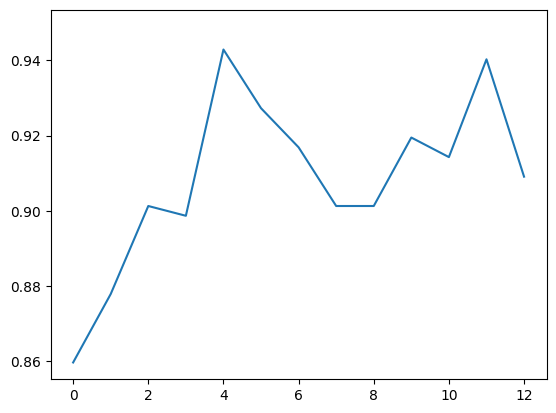

In [33]:
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

다음 그림은 훈련과 테스트 데이터에 대해 에포크가 진행될 때마다 정확도를 출력한 겨로가입니다. 훈련 테스트 데이터 모두 에포크가 진행될수록 정확도가 높아지면서 100% 가까워지고 있습니다, 실제로 더 많은 에포크를 진행한다면 더욱더 100%에 수렴하는 것을 확인할 수 있습니다.

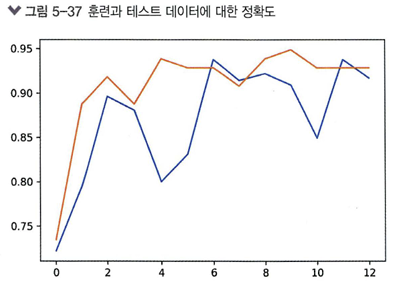

이번에는 오차 정보를 그래프로 살펴보겠습니다.

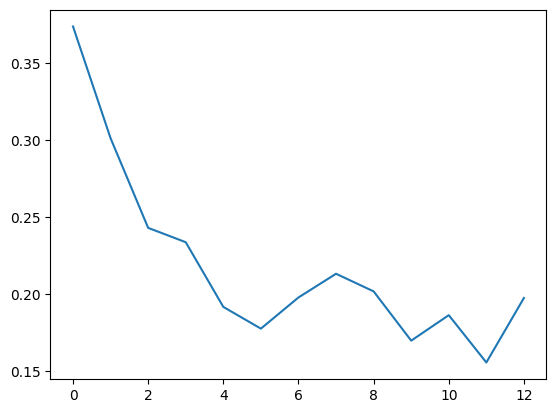

In [34]:
plt.plot(train_loss_hist)
plt.show()

훈련 데이터에 대해 에포크가 진행될 때마다 오차를 출력한 결과입니다. 에포크가 진행될수록 오차가 낮아지고 있기 때문에 학습이 잘되었다고 할 수 있습니다.

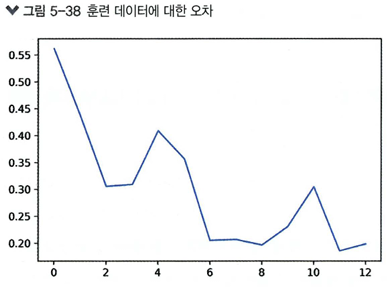

단순히 정확도와 오차 정보를 확인하는 것에 머무르지 않고, 실제로 데이터를 잘 예측하는지 살펴보겠습니다. 먼저 예측된 이미지를 출력하기 위한 전처리 함수를 생성합니다.

In [35]:
def im_convert(tensor):
  image = tensor.clone( ).detach( ).numpy () #1
  image = image.transpose(1, 2, 0)
  image = image * (np.array((0.5,0.5,0.5)) + np.array((0.5,0.5,0.5)))
  image = image.clip( 0, 1) #2
  return image

- 1 tensor.clone()은 기존 텐서의 내용을 복사한 텐서를 생성하겠다는 의미이며, detach()는 기존 텐서에서 기울기가 전파되지 않는 텐서이다. 즉, tensor.clone(). detach()는 기존 텐서를 복사한 새로운 텐서를 생성하지만 기울기에 영향을 주지 않겠다는 의미이다.
다음은 tensor.clone(), tensor.detach(), tensor.clone().detach()를 비교한 표이다.

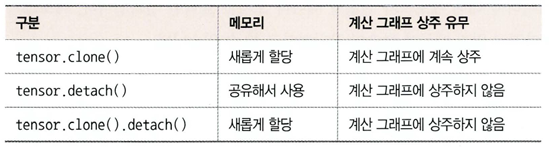

- 계산 그래프
계산 그래프란 계산 과정을 그래프로 나타낸 것이다. 그래프는 여러 개의 노드와 그 노드들을 연결하는 선인 에지로 구성된다.

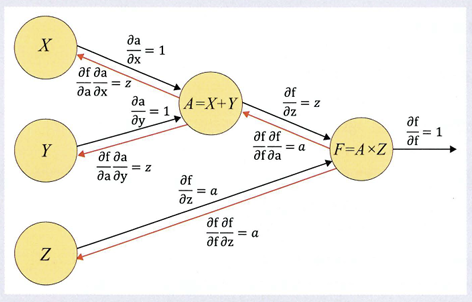

계산 그래프를 사용하는 이유는 두 가지이다.

- 국소적 계산이 가능하다. 국소적 계산이 가능하다는 의미는 Z값이 변경되었자면 X,Y 계산 결과를 그대로 유지한 채로 바뀐 Z의 연산이 필요한 F=AxZ만 계산하면 된다.

- 역전파를 통한 미분 계산이 편리하다. 주황색 선이 역전파를 구하는 과정을 보여 주는데 연쇄 법칙을 이용하여 빠르고 간편하게 미분을 계산할 수 있다.

- 연쇄 법칙

두 개 이상의 함수가 결합된 함수, 즉 합성 함수의 미분법을 연쇄 법칙 혹은 체인룰이라고 한다. 예를 들어 다음 그림과 같이 z=(x+y)^2을 z=t^2와 t=x+y의 합성함수로 표현하고 각 합성 함수의 미분 결과를 곱한 결과로 나타내는 것이 연쇄 법칙이다.

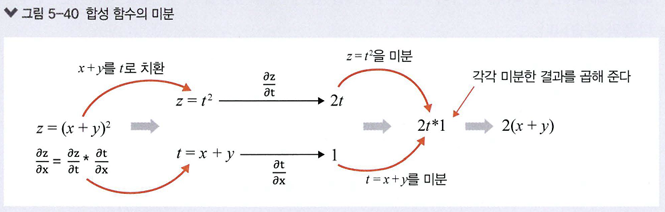

- 2 clip()은 입력 값이 주어진 범위를 벗어날 때 입력 값을 특정 범위로 제한시키기 위해 사용한다. 즉, image.clip(0,1)은 image 데이터를 0과 1 사이의 값으로 제한하겠다는 의미이다.

In [36]:
import numpy as np
exam=np.array([-1.8,-1.2,-0.7,0.0,0.8,1.4,1.9])
print(exam)
print(np.clip(exam,-0.5,0.5))

[-1.8 -1.2 -0.7  0.   0.8  1.4  1.9]
[-0.5 -0.5 -0.5  0.   0.5  0.5  0.5]


이제 테스트 데이터셋을 이용하여 실제로도 개와 고양이를 잘 분류하는지 살펴본다.

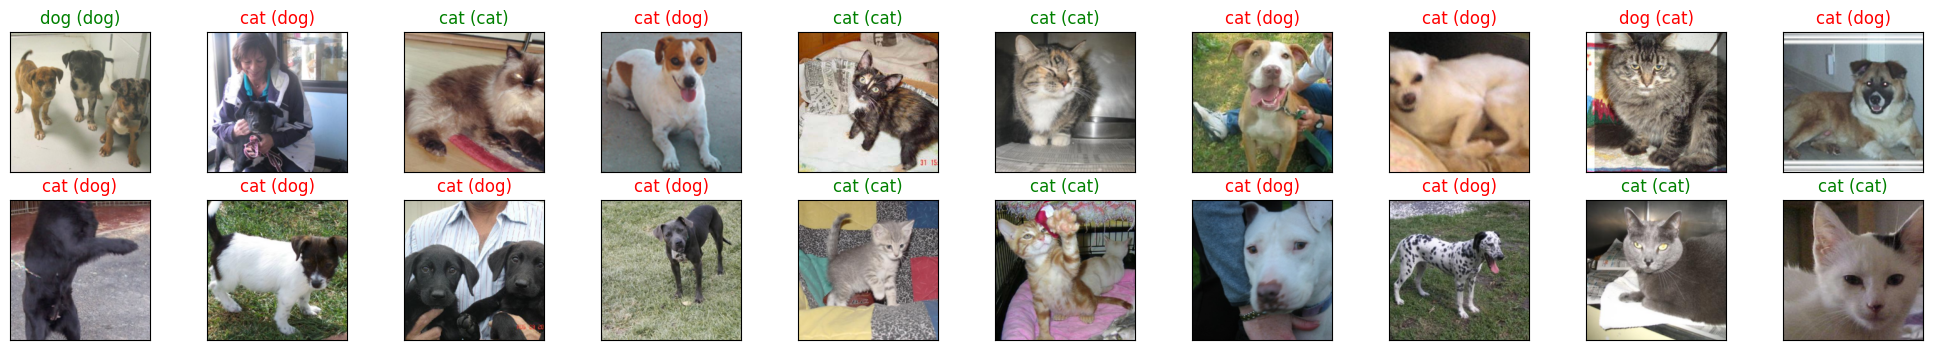

<Figure size 640x480 with 0 Axes>

In [37]:
classes = {0: 'cat', 1: 'dog' } # 개와 고앙이 두 개에 대한 레이블
dataiter = iter(test_loader) #테스트 데이터셋을 가져옵니다
images, labels = next(dataiter) # 테스트 데이터셋에서 이미지와 레이블을 분리하여 가져옵니다.
output = model(images)
_, preds = torch.max(output, 1)


fig = plt.figure(figsize=(25,4))
for idx in np.arange(20):
  ax = fig .add_subplot(2, 10, idx+1 , xticks=[] , yticks=[]) #1
  plt. imshow (im_convert (images [idx] )) #이미지 출력을 위해 코드 5-28에서 정의한 im_convert 함수를 적용
  a.set_title(classes[labels[i].item()])
  ax.set_title("{} ({})" .format(str(classes[preds [idx].item()]), str(classes[labels[idx]. item()])), color=( "green" if preds [idx]==labels[idx] else "red" )) #2
plt. show()
plt. subplots_adjust(bottom=0.2, top=0.6, hspace=0) #3

- add_subplot은 한 화면에 여러 개의 이미지를 담기 위해 사용한다. 이때 사용되는 파라미터는 다음과 같다.
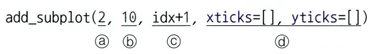

 + a. 첫 번째 파라미터: 행의 수를 의미하는데, 이미지를 두 줄로 출력한다.
 + b. 두 번째 파라미터: 열의 수를 의미하는데, 한 줄에 열 개의 이미지를 출력한다.
 + c. 세 번째 파라미터: 인덱스를 의미하는데, 행과 열을 기준으로 순차적으로 이미지를 출력한다.
 + d. 네 번째 파라미터: 틱(tick)을 삭제하겠다는 의미이다. 참고로 틱의 의미는 다음과 같다.
 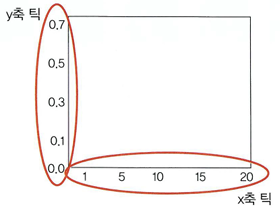

- 2 classes[preds[idx].item()]은 preds[[idx].item()] 값이 0이면 고양이, 1이면 개로 출력된다.

- 3 다음 그림과 같이 Figure 안에서 서브플롯(다음 그림에서 Axes에 해당)의 위치를 조정할 때 사용한다. left, bottom, right, top으로 이미지 위치를 조정한다. 또한, hspace와 wspace를 사용해서 서브플롯 간의 간격(너비와 높이의 비율)을 조정할 수 있다.

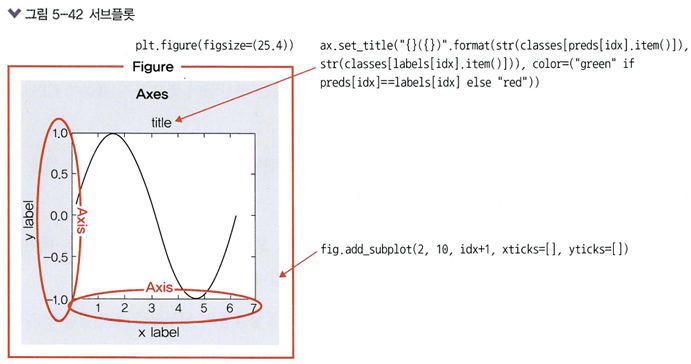

다음 그림은 개와 고양이에 대한 예측 결과이다. 초록색은 개와 고양이를 정확하게 예측한 것이고, 빨간색은 예측이 잘못되었음을 의미한다.

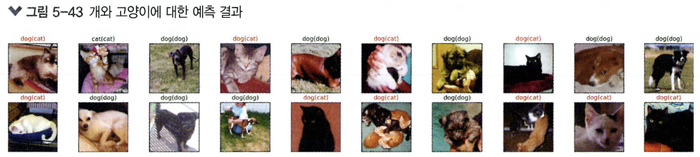

결과를 살펴보니 예측이 정확하지 않은 것을 확인할 수 있다. 훈련 데이터를 더 늘리고, 에포크 횟수도 늘려 보면 더 좋은 결과를 얻을 수 있다.

### 5.3.2 미세 조정 기법
미세 조정 기법은 특성 추출 기법에서 더 나아가 사전 훈련된 모델과 합성곱층, 데이터 분류기의 가중치를 업데이트하여 훈련시키는 방식이다. 특성 추출은 목표 특성을 잘 추출했다는 전제하에 좋은 성능을 낼 수 있다. 특성이 잘못 추출되었다면(예를 들어 ImageNet 데이터셋의 이미지 특징과 전자상거래 물품의 이미지 특징이 다르다면) 미세 조정 기법으로 새로운(전자상거래) 이미지 데이터를 사용하여 네트워크의 가중치를 업데이트해서 특성을 다시 추출할 수 있다. 즉, 사전 학습된 모델을 목적에 맞게 재학습시키거나 학습된 가중치의 일부를 재학습시키는 것이다. 미세 조정 기법은 사전 훈련된 네트워크를 미세 조정하여 분석하려는 데이터셋에 잘 맞도록 모델의 파라미터를 조정하는 기법이다. 미세 조정 과정에서 많은 연산량이 필요하기 때문에 CPU보다는 GPU를 사용하길 권장한다. 미세 조정 기법은 훈련시키려는 데이터셋의 크기와 사전 훈련된 모델에 따라 다음 전략으 세울 수 있다.
- 데이터셋이 크고 사전 훈련된 모델과 유사성이 작을 경우: 모델 전체를 재학습시킨다. 데이터셋 크기가 크기 때문에 재학습시키는 것이 좋은 전략이다.
- 데이터셋이 크고 사전 훈련된 모델과 유사성이 클 경우: 합성곱층의 뒷부분(완전연결층과 가까운 부분)과 데이터 분류기를 학습시킨다. 데이터셋이 유사하기 때문에 전체를 학습시키는 것보다는 강한 특징이 나타나는 합성곱층 뒷부분과 데이터 분류기만 새로 학습하더라도 최적의 성능을 낼 수 있다.
- 데이터셋이 작고 사전 훈련된 모델과 유사성이 작을 경우: 합성곱층의 일부분과 데이터 분류기를 학습시킨다. 데이터가 적기 때문에 일부 계층에 미세 조정 기법을 적용한다고 해도 효과가 없을 수 있다. 따라서 합성곱층 중 어디까지 새로 학습시켜야 할지 적당히 설정해주어야 한다.
- 데이터셋이 작고 사전 훈련된 모델과 유사성이 큰 경우: 데이터 분류기만 학습시킨다. 데이터가 적기 때문에 많은 계층에 미세 조정 기법을 적용하면 과적합이 발생할 수 있다. 따라서 최종 데이터 분류기인 완전연결층에 대해서만 미세 조정 기법을 적용한다.

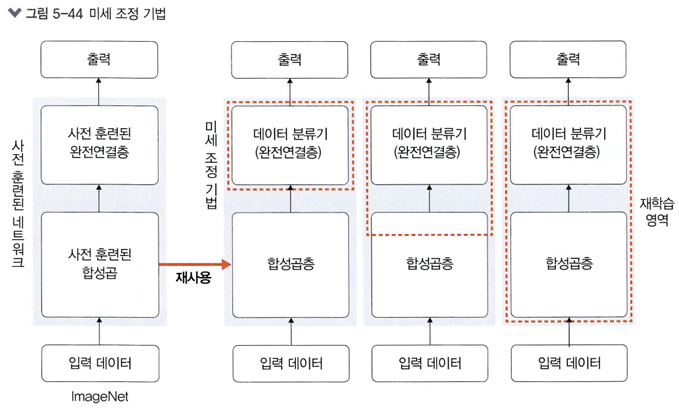

미세 조정은 파라미터 업데이트 과정에서 파라미터에 큰 변화를 주게 되면 과적합 문제가 발생할 수 있기 때문에 정교하고 미세한 파라미터 업데이트가 필요하다.